# Project 1: Motor Insurance Pricing and Risk Modeling

## Overview

This project explores motor insurance claim frequency modeling using a real-world insurance portfolio dataset.

The objective is to study how policyholder, vehicle, and geographic characteristics influence insurance risk and expected claim frequency.

The project follows a pricing-oriented actuarial workflow:

1. Understand the dataset structure
2. Perform exploratory data analysis (EDA)
3. Clean and prepare insurance exposure data
4. Model claim frequency using a Poisson Generalized Linear Model (GLM)
5. Interpret rating factors and risk segmentation
6. Estimate scenario-based premiums
7. Prepare the project for future severity and pure premium modeling


## Business Context

In property and casualty insurance, insurers must estimate the expected future cost of each policy.

A simplified pricing framework is:

Pure Premium = Claim Frequency × Claim Severity

Where:

- Claim Frequency measures how often claims occur
- Claim Severity measures how costly those claims are

This notebook focuses primarily on the frequency component because the current dataset contains:

- policy exposure
- claim counts
- driver characteristics
- vehicle characteristics
- regional information

but does not yet include detailed claim amount severity information.

---

## Dataset Description

The dataset contains motor insurance policy records.

Each row represents a single insurance policy.

Key variables include:

| Variable | Description |
|---|---|
| ClaimNb | Number of claims |
| Exposure | Policy exposure duration |
| DrivAge | Driver age |
| VehAge | Vehicle age |
| VehPower | Vehicle power category |
| BonusMalus | Risk/bonus score |
| Area | Area category |
| Region | Geographic region |
| Density | Population density |
| VehGas | Fuel type |
| VehBrand | Vehicle brand category |

---

## Modeling Objective

The primary modeling objective is to estimate expected claim frequency using a Poisson GLM with exposure adjustment.

The project also aims to:

- identify major insurance risk drivers
- understand relationships between rating variables and claims
- create interpretable risk segmentation
- simulate pricing-oriented outputs
- build a foundation for future severity and pure premium modeling

---

## Statistical Background

Insurance claim counts are discrete count outcomes:

0, 1, 2, 3, ...

Most policyholders generate no claims, while a smaller number generate one or more claims.

Because of this structure, Poisson regression is commonly used as a baseline actuarial frequency model.

Exposure is included as a log offset so the model estimates claim frequency rather than raw claim count.

---

## Future Extensions

Planned future extensions include:

- Severity modeling using Gamma GLMs
- Pure premium modeling
- Tweedie GLMs
- XGBoost comparison models
- Train/test validation
- Advanced residual diagnostics
- Dashboard visualization

---

## Technical Stack

- Python
- Pandas
- NumPy
- Statsmodels
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## References and Study Sources

This project is conceptually aligned with:

- CAS Exam 5: Basic Ratemaking
- SOA SRM / CAS MAS-I GLM concepts
- Generalized Linear Models for Insurance Rating (CAS Monograph)
- Basic Ratemaking by Werner and Modlin

---

# Project 1: Motor Insurance Pricing and Risk Modeling

## Objective

The objective of this project is to analyze a motor insurance portfolio and model claim frequency using actuarial pricing techniques.

The project explores how policyholder, vehicle, and geographic characteristics influence insurance risk.

A Poisson Generalized Linear Model (GLM) is used to estimate expected claim frequency while adjusting for exposure.

This project is designed as a pricing-oriented actuarial analytics case study and will later be extended to include severity and pure premium modeling.

In [66]:
import pandas as pd

df = pd.read_csv("../data/raw/motor-insurance-frequency.csv")

df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'


In [67]:
df = df.rename(columns={
    "DrivAge": "Age",
    "Area": "Region"
})
df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Region', 'VehPower', 'VehAge', 'Age',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Region      678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   Age         678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


In [69]:
df.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,Age,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [70]:
df["ClaimNb"].value_counts()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64

In [71]:
required_cols = ["Age","VehAge","VehPower","Exposure","ClaimNb"]

df = df.dropna(subset=required_cols).copy()
df = df[df["Exposure"] > 0]

In [72]:
df["Age"] = df["Age"].clip(lower=18, upper=90)
df["VehAge"] = df["VehAge"].clip(lower=0, upper=30)

In [73]:
df["claim_frequency"] = df["ClaimNb"] / df["Exposure"]

In [74]:
df["age_band"] = pd.cut(
    df["Age"],
    bins=[17,25,35,45,55,65,100],
    labels=["18-25","26-35","36-45","46-55","56-65","65+"]
)

C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\934045436.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_freq = df.groupby("age_band").apply(
C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\934045436.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_freq = df.groupby("age_band").apply(


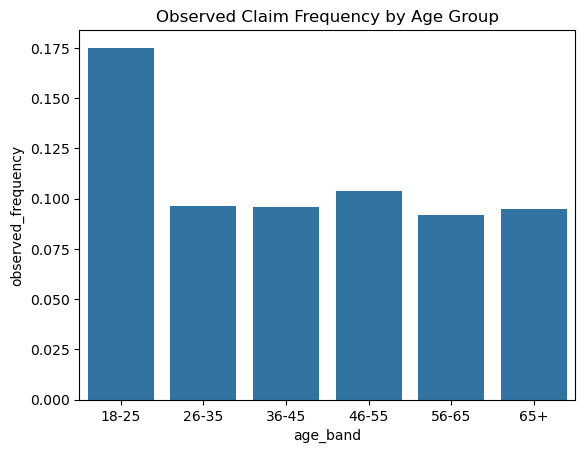

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

age_freq = df.groupby("age_band").apply(
    lambda x: x["ClaimNb"].sum()/x["Exposure"].sum()
).reset_index(name="observed_frequency")

sns.barplot(data=age_freq, x="age_band", y="observed_frequency")
plt.title("Observed Claim Frequency by Age Group")
plt.show()

In [76]:
plt.savefig("../output/figures/claim_frequency_by_age_band.png")

<Figure size 640x480 with 0 Axes>

In [77]:
import statsmodels.api as sm
import numpy as np
model_df = df[["Age","VehAge","VehPower","Exposure","ClaimNb"]].copy()

X = model_df[["Age","VehAge","VehPower"]]
X = sm.add_constant(X)

y = model_df["ClaimNb"]

model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=np.log(model_df["Exposure"])
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678009
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4599e+05
Date:                Sat, 23 May 2026   Deviance:                   2.2265e+05
Time:                        12:28:45   Pearson chi2:                 1.84e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002698
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8012      0.026    -70.582      0.0

In [78]:
df["predicted_claims"] = model.predict(
    X,
    offset=np.log(model_df["Exposure"])
)

df["predicted_frequency"] = df["predicted_claims"] / df["Exposure"]

In [79]:
average_claim_cost = 3000

df["estimated_premium"] = df["predicted_frequency"] * average_claim_cost

In [80]:
segment = df.groupby("age_band").agg(
    avg_frequency=("predicted_frequency","mean"),
    avg_premium=("estimated_premium","mean")
).reset_index()

segment

C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\1411004983.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment = df.groupby("age_band").agg(


,age_band,avg_frequency,avg_premium
0,18-25,0.110828,332.482893
1,26-35,0.111075,333.225892
2,36-45,0.105882,317.646624
3,46-55,0.101993,305.979945
4,56-65,0.099240,297.719014
5,65+,0.091908,275.725376


In [81]:
segment.to_csv("../output/segment_summary.csv",index=False)